Import libraries. Make sure to download numpy, pandas, geopandas, matplotlib, seaborn, and gerrychain

In [8]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Georgia case study
"""
#--Import Libraries
import os
import sys
import re

import csv
import json
import random
import math
import numpy as np

from functools import partial
import pandas as pd
import geopandas as gpd

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import gerrychain as gc 
from gerrychain import (
     Election,
     Graph,
     MarkovChain,
     Partition,
     accept,
     constraints,
     updaters
     
)
from gerrychain.metrics import efficiency_gap, mean_median, polsby_popper, wasted_votes, partisan_bias
from gerrychain.proposals import recom, propose_random_flip 
from gerrychain.updaters import cut_edges
from gerrychain.tree import recursive_tree_part, bipartition_tree_random
from gerrychain.accept import always_accept

import urllib.request # not included in original code. added to import data.

<Axes: >

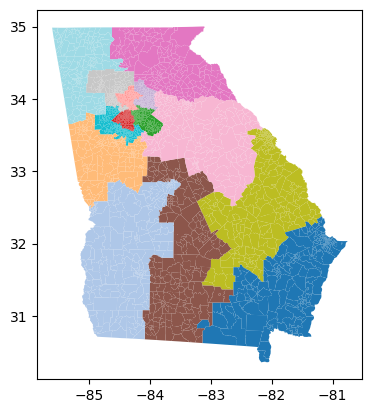

In [9]:
# plt.style.use('seaborn-whitegrid')

# Download the files
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/uwescience/dssg2021-redistricting/refs/heads/main/Georgia/Data/GA_precincts.json",
    "GA_precincts.json"
)
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/uwescience/dssg2021-redistricting/refs/heads/main/Georgia/Data/GA_precincts.zip",
    "GA_precincts.zip"
)

# Now load them from local paths
graph = Graph.from_json("GA_precincts.json")
df = gpd.read_file("GA_precincts.zip")
#--Eyeballing the state 
df.plot(column="CD", cmap="tab20")


SET UP VARIABLES AND FUNCTIONS

In [11]:
#--Set some parameters based on GA 
state_abbr="GA"
housen="CON"
num_districts=14
pop_col="TOTPOP"
#num_elections=4

In [12]:
#Make an output directory to put files in
newdir = "./Outputs/"+state_abbr+housen+"_Precincts/"
os.makedirs(newdir, exist_ok=True)
with open(newdir + "init.txt", "w") as f:
    f.write("Create Folder")

In [ ]:
#--Generic updaters
# Population updater, for computing how close to equality the district
# populations are. "TOTPOP" is the population column from our shapefile.
updater = {
    "population": updaters.Tally("TOTPOP", alias="population"),
    "cut_edges": cut_edges
             }

#--Set some parameters based on analysis
#PRES16D - number of votes for 2016 democratic presidential candidate
#PRES16R - number of votes for 2016 Republican presidential candidate
#SEN16D - number of votes for 2016 democratic senate candidate
#SEN16R - number of votes for 2016 Republican senate candidate
#VAP - Total voting age population
#HVAP - Hispanic voting age population
#WVAP - White, non-hispanic, voting age population
#BVAP - Black, non-hispanic, voting age population
#CD - US congressional district
#HDIST - Georgia House district
#SEND - Georgia Senate district
 
election_names=[
    "PRES16",
    # "SEN16",
    "BVAP",
    "HVAP",
    "WVAP",
    "BHVAP"]

num_elections = len(election_names)

election_columns=[
    ["PRES16R", "PRES16D"],
    # ["SEN16R", "SEN16D"],
    ["BVAP", "nBVAP"],
    ["HVAP", "nHVAP"],
    ["WVAP", "nWVAP"],
    ["BHVAP", "nBHVAP"]
    ]
    
#--Setup election updaters
# Election updaters, for computing election results using the vote totals
# from our shapefile.
elections = [
    Election(
        election_names[i], #Name of election
        {"First": election_columns[i][0], "Second": election_columns[i][1]},
        )
        for i in range(num_elections)
] 

election_updaters = {election.name: election for election in elections} 

updater.update(election_updaters)

In [ ]:
#Coerce tabular data to correct type
totpop = 0 
for n in graph.nodes():
    totpop+= graph.nodes[n]["TOTPOP"]#The loop is going over all the precincts then adding the populations
    graph.nodes[n]["TOTPOP"] = int(graph.nodes[n]["TOTPOP"])
    graph.nodes[n]["VAP"] = int(graph.nodes[n]["VAP"])
    graph.nodes[n]["BVAP"] = int(graph.nodes[n]["BVAP"])
    graph.nodes[n]["HVAP"] = int(graph.nodes[n]["HVAP"])
    graph.nodes[n]["WVAP"] = int(graph.nodes[n]["WVAP"])
    graph.nodes[n]["CD"] = int(graph.nodes[n]["CD"])
    graph.nodes[n]["PRES16R"] = int(graph.nodes[n]["PRES16R"])
    graph.nodes[n]["PRES16D"] = int(graph.nodes[n]["PRES16D"])
    
#Generating populations
    graph.nodes[n]["nBVAP"] = graph.nodes[n]["VAP"] - graph.nodes[n]["BVAP"]
    graph.nodes[n]["nHVAP"] = graph.nodes[n]["VAP"] - graph.nodes[n]["HVAP"]
    graph.nodes[n]["nWVAP"] = graph.nodes[n]["VAP"] - graph.nodes[n]["WVAP"]
    graph.nodes[n]["BHVAP"] = graph.nodes[n]["BVAP"] + graph.nodes[n]["HVAP"]
    graph.nodes[n]["nBHVAP"] = graph.nodes[n]["VAP"] - graph.nodes[n]["BHVAP"]


Create a random seed plan.

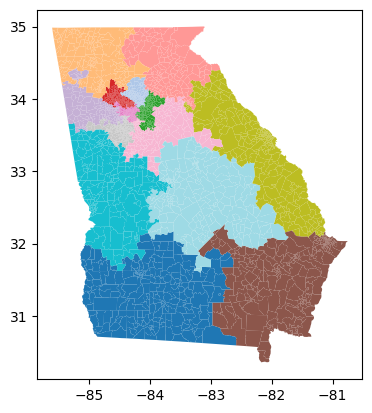

In [16]:
#--Create, Plot, and save seed plan           
cddict = recursive_tree_part(graph,
                                range(num_districts),
                                totpop/num_districts,
                                "TOTPOP",
                                .01, #1% population balance
                                1)
df['initial'] = df.index.map(cddict)
df.plot(column="initial", cmap="tab20")#cmap stand for color map
plt.savefig(newdir+"initial.png")
plt.show()
plt.close()

Save the seed plan as a json file

In [17]:
with open(newdir+"init.json", 'w') as jf1:
          json.dump(cddict, jf1) 

Build initial Partition - combining the graph of GA, the initial seed plan, and the updaters into one object.

In [18]:
# Build initial Partition
initial_partition = Partition(graph,
                              cddict,
                              updater)

#Build initial Partition
# initial_partition = Partition(graph,
#                               "CD",
#                               updater)

These lines are used to retrieve information. They don't do anything but check if the information is loaded into initial_partition correctly.

In [ ]:
initial_partition["PRES16"].counts("First")

initial_partition['population']

initial_partition.parts

Saves statistics about the seed plan to a text file - things like cut edges, election percentages, mean-median score, efficiency gap, and wasted vote per district per election.

In [20]:
#Write out initial statistics to file (seed plan)
with open(newdir + "Start_Values.txt", "w") as f: 
    f.write("Values for Starting Plan: Tree Recursive\n \n ")
    f.write("Initial Cut: " + str(len(initial_partition["cut_edges"])))
    f.write("\n")
    f.write("\n")

    for elect in range(num_elections):
        f.write(
            election_names[elect]
            + "District Percentages"
            + str(
                (initial_partition[election_names[elect]].percents("First"))
            )
        )
        f.write("\n")
        f.write("\n")

        f.write(
            election_names[elect]
            + "Mean-Median :"
            + str(mean_median(initial_partition[election_names[elect]]))
        )

        f.write("\n")
        f.write("\n")

        f.write(
            election_names[elect]
            + "Efficiency Gap :"
            + str(efficiency_gap(initial_partition[election_names[elect]]))
        )

        f.write("\n")
        f.write("\n")

        f.write(
            election_names[elect]
            + "How Many Seats :"
            + str(initial_partition[election_names[elect]].wins("First"))
        )

        f.write("\n")
        f.write("\n")
        
        for dist in range(14):
            f.write(
                election_names[elect]    #wasted votes
                + "Wasted Votes :"
                + str(wasted_votes(initial_partition[election_names[elect]].votes("First")[dist],
                                   initial_partition[election_names[elect]].votes("Second")[dist]))
            )
    
            f.write("\n")
            f.write("\n")

Initialize a Proposal (ReCom). Ideal population (average population size) and maximum deviation value are needed.

In [21]:
#Initialize Proposal (ReCom)
#af
# ajds;ak;faj
# The ReCom proposal needs to know the ideal population for the districts so that
# we can improve speed by bailing early on unbalanced partitions.

ideal_population = sum(initial_partition["population"].values())/ len(initial_partition)
#ajds;ak;faj
# We use functools.partial to bind the extra parameters 
#(pop_col, pop_target, epsilon, node_repeats) of the recom proposal.
proposal = partial(
    recom, pop_col="TOTPOP", 
    pop_target=ideal_population, 
    epsilon=0.01, #1% deviations population balance
    node_repeats=1,
    method = bipartition_tree_random
)    

Creates constraints: compactness and population constraints. The final generated map is bound to have at most 2 times the number of cut edges in the initial plan. This prevents the generated map from having jagged shapes. The population constraint will be used to reject maps that have districts that exceed the 1% deviation.

In [22]:
#Create Constraints (compactness)
#To keep districts about as compact as the original plan, 
#we bound the number of cut edges at 2 times the number 
#of cut edges in the initial plan.
compactness_bound = constraints.UpperBound(
    lambda p: len(p["cut_edges"]),
    2*len(initial_partition["cut_edges"]) 
)

pop_constraint = constraints.within_percent_of_ideal_population(initial_partition, 0.01)  #change from 0.02 for GA population balance         

Optional acceptance function(s). Acceptance functions can be useful if we want to analyze maps with specific characteristics, like certain percentage of voters in a district. Not having an acceptance function means we accept all proposed maps.

In [ ]:
#Create Acceptance Function(s)
#Build a constraint that rejects a plan if there is a district with over 60% vote in PRES16
# def sixty_PRES16_accept(partition): 
    
    
#     new = sum(x<.6 for x in partition["PRES16"].percents("First"))
    
#     old = sum(x<.6 for x in partition.parent["PRES16"].percents("First"))
    
#     if new > old:       
#         return True
    
#     else:
#         return False 
    
# #Build a constraint that rejects a plan if there is a district with BVAP% over 60%
# def sixty_BVAP_accept(partition): 
    
    
#     new = sum(x<.6 for x in partition["BVAP"].percents("First"))
    
#     old = sum(x<.6 for x in partition.parent["BVAP"].percents("First"))
    
#     if new > old:       
#         return True
    
#     else:
#         return False 
    
# #Build a constraint that rejects a plan if there is a district with WVAP% over 60%
# def sixty_WVAP_accept(partition): 
    
    
#     new = sum(x<.6 for x in partition["WVAP"].percents("First"))
    
#     old = sum(x<.6 for x in partition.parent["WVAP"].percents("First"))
    
#     if new > old:       
#         return True
    
#     else:
#         return False 
    
# #Build a constraint that rejects a plan if there is a district with HVAP% over 60%
# def sixty_HVAP_accept(partition): 
    
    
#     new = sum(x<.6 for x in partition["HVAP"].percents("First"))
    
#     old = sum(x<.6 for x in partition.parent["HVAP"].percents("First"))
    
#     if new > old:       
#         return True
    
#     else:
#         return False

Assembles everything into a Markov chain that will generate 2000 different redistricting maps, each one a small random modification of the previous, all satisfying the constraints. always_accept means every valid proposed map is accepted.

In [23]:
#Create Markov Chains
recom_chain = MarkovChain(
    proposal=proposal,
    constraints=[
        constraints.within_percent_of_ideal_population(initial_partition, 0.01), #changed from 0.05
        compactness_bound, 
    ],
    accept=accept.always_accept, 
    initial_state=initial_partition,
    total_steps= 2000 #changed from 1000
)


Runs the Chain and Collect Results.
This is the main loop. For each election/demographic metric, it runs all 2000 steps and at each step: records partisan bias, records wasted votes per district, saves a map image of that plan. After all steps, saves the results to CSV files.

The result of this part of the code is truncated, at least it is on Jupyter Notebook, because there are too many maps to save.

In [24]:
#Run Recom Chain and collect results
#Testing whether 60% acceptance function is feasible for PRES16, BVAP, WVAP, HVAP
  # for dist in range(14):
  #           f.write(
  #               election_names[elect]    #wasted votes
  #               + "Wasted Votes :"
  #               + str(wasted_votes(initial_partition[election_names[elect]].votes("First")[dist],
  #                                  initial_partition[election_names[elect]].votes("Second")[dist]))
  #           )
# sixty_PRES16 = []
for elect in range (num_elections):
    pbs= []
    wv = [[],[],[],[],[],[],[],[],[],[],[],[],[],[]]
    step_num = 0
    for part in recom_chain:
        pbs.append(partisan_bias(part["PRES16"]))
      
        # for dist in range(14):
        #     wv[dist].append()#WASTED VOTES FUNCTION goes here)
        # df['recom'] = df.index.map(dict(part.assignment)) #new plan
        # df.plot(column="recom",cmap='tab20')
        # #plt.show()
        # step_num +=1
        # plt.savefig(newdir+f"./plan{step_num}.png")
        # plt.close()
    
        for dist in range(14):
            wv[dist].append(wasted_votes(part[election_names[elect]].votes("First")[dist],
                                          part[election_names[elect]].votes("Second")[dist]))#WASTED VOTES FUNCTION goes here)
        df['recom'] = df.index.map(dict(part.assignment)) #new plan
        df.plot(column="recom",cmap='tab20')
        #plt.show()
        step_num +=1
        plt.savefig(newdir+f"./plan{step_num}.png")
        plt.close()
        
    with open(newdir + "run0/pbs/pbs" + election_names[elect] + str(step_num) + ".csv", "w") as tf1:
        writer = csv.writer(tf1, lineterminator="\n")
        writer.writerow(pbs)
        
    for dist in range(14):   
        with open(newdir + "run0/wv/" + election_names[elect] + "_" + str(dist) + "_" + str(step_num) + ".csv", "w") as tf1:
            writer = csv.writer(tf1, lineterminator="\n")
            writer.writerows(wv[dist])

PopulationBalanceError: 

This section was written to read back the saved CSV files and plot results. Since the code is commented, it was likely carried out in another script.

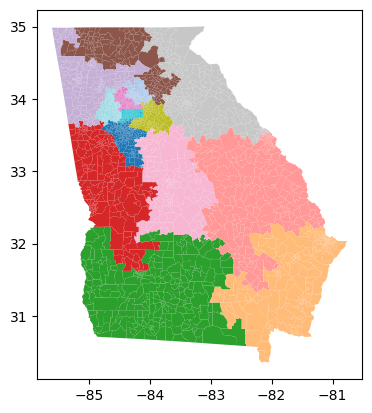

PopulationBalanceError: 

In [ ]:
#     sixty_PRES16.append(sum(x<.6 for x in part["PRES16"].percents("First"))) 

# plt.plot(sixty_PRES16) #number of competitive districts below 60%

# sixty_BVAP = []

# for part in recom_chain:
    
#     sixty_BVAP.append(sum(x<.6 for x in part["BVAP"].percents("First"))) 

# plt.plot(sixty_BVAP) #number of competitive districts below 60% for BVAP

# sixty_WVAP = []

# for part in recom_chain:
    
#     sixty_WVAP.append(sum(x<.6 for x in part["WVAP"].percents("First"))) 

# plt.plot(sixty_WVAP) #number of competitive districts below 60% for WVAP

# sixty_HVAP = []

# for part in recom_chain:
    
#     sixty_HVAP.append(sum(x<.6 for x in part["PRES16"].percents("First"))) 

# plt.plot(sixty_HVAP) #number of competitive districts below 60% for HVAP

              
   
#Read in written data to plot (usually would be a separate script)
# sns.set_style('darkgrid')
#sns.set_style("darkgrid", {"axes.facecolor": ".97"})


#datadir = "./Outputs/MACON_Precincts/" #Have to change path?


#os.makedirs(os.path.dirname(newdir + "init.txt"), exist_ok=True)
#with open(newdir + "init.txt", "w") as f:
#    f.write("Created Folder")


#max_steps = 2000
#step_size = 400

#ts = [x * step_size for x in range(1, int(max_steps / step_size) + 1)]

#seats = []

#mms = []

#for t in ts:  #
#    for s in range(step_size):
#        seats.append(temp[s, :])

#    temp = np.loadtxt(datadir + "mms" + str(t) + ".csv", delimiter=",")
#    for s in range(step_size):
#        mms.append(temp[s, :])

#seats = np.array(seats)
#mms = np.array(mms)
            